# TE Group Visual Analysis

这个 notebook 的目标不是直接训练模型，而是**严谨判断哪些 Target Encoding 分组值得进入下一轮实验**。

核心问题：

- 哪些是粗粒度 TE？哪些是中粒度 TE？
- 每个 TE 分组在 `train` / `test` 中覆盖情况如何？
- 是否存在大量 test unseen group？
- train 中每个 group 的样本数是否足够？
- target rate 的差异是真信息，还是小样本噪声？

本 notebook 的定义：

- **coarse TE**：单字段 TE，例如 `Compound_TE`、`Race_TE`、`Year_TE`、`Driver_TE`、`Stint_TE`
- **mid TE**：两个字段组合 TE，例如 `Stint x Compound`、`Race x Stint`
- **high-risk TE**：包含 `Driver` 的组合，通常容易稀疏，先只观察，不作为主线候选

判断方向：

- 优先看 `test_unseen_row_pct`：test 中有多少行的组合在 train 没出现过
- 再看 `test_low_count_row_pct`：test 中有多少行对应 train group 样本太少
- 再看 `target_rate_std` 和图：target 差异是否主要由小 group 拉出来

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

DATA_DIR = Path('.')
if not (DATA_DIR / 'train.csv').exists():
    DATA_DIR = Path('playground-s6e5')

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
TARGET = 'PitNextLap'
ID_COL = 'id'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print('train:', train.shape)
print('test :', test.shape)
print('target mean:', train[TARGET].mean())
display(train.head())
display(test.head())

train: (439140, 16)
test : (188165, 15)
target mean: 0.19898210137996994


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


## 1. Define TE Groups

这里故意把候选分得很清楚：

- `coarse_specs`：单字段 TE，用来验证粗粒度信息是否已经被 baseline 吸收
- `mid_specs_main`：更建议验证的中粒度组合，不包含 Driver
- `mid_specs_existing_or_related`：baseline 可能已经有或者高度相关的组合，用来做对照
- `high_risk_driver_specs`：Driver 相关组合，只观察稀疏性，不建议优先提交

In [2]:
coarse_specs = {
    'Compound_TE': ['Compound'],
    'Race_TE': ['Race'],
    'Year_TE': ['Year'],
    'Driver_TE': ['Driver'],
    'Stint_TE': ['Stint'],
    'PitStop_TE': ['PitStop'],
    'Position_TE': ['Position'],
}

mid_specs_main = {
    'Stint_Compound_TE': ['Stint', 'Compound'],
    'Race_Stint_TE': ['Race', 'Stint'],
    'Year_Stint_TE': ['Year', 'Stint'],
    'Year_Compound_TE': ['Year', 'Compound'],
    'PitStop_Stint_TE': ['PitStop', 'Stint'],
    'Position_Stint_TE': ['Position', 'Stint'],
}

mid_specs_existing_or_related = {
    'Race_Compound_TE': ['Race', 'Compound'],
    'Race_Year_TE': ['Race', 'Year'],
    'Race_Year_Compound_TE': ['Race', 'Year', 'Compound'],
}

high_risk_driver_specs = {
    'Driver_Race_TE': ['Driver', 'Race'],
    'Driver_Compound_TE': ['Driver', 'Compound'],
    'Driver_Stint_TE': ['Driver', 'Stint'],
    'Driver_Race_Compound_TE': ['Driver', 'Race', 'Compound'],
}

GROUP_SPECS = {}
GROUP_TYPE = {}
for name, cols in coarse_specs.items():
    GROUP_SPECS[name] = cols
    GROUP_TYPE[name] = 'coarse_single_field'
for name, cols in mid_specs_main.items():
    GROUP_SPECS[name] = cols
    GROUP_TYPE[name] = 'mid_main_candidate'
for name, cols in mid_specs_existing_or_related.items():
    GROUP_SPECS[name] = cols
    GROUP_TYPE[name] = 'mid_existing_or_related'
for name, cols in high_risk_driver_specs.items():
    GROUP_SPECS[name] = cols
    GROUP_TYPE[name] = 'high_risk_driver_combo'

pd.DataFrame([
    {'te_name': name, 'type': GROUP_TYPE[name], 'columns': ' x '.join(cols), 'n_columns': len(cols)}
    for name, cols in GROUP_SPECS.items()
])

,te_name,type,columns,n_columns
0,Compound_TE,coarse_single_field,Compound,1
1,Race_TE,coarse_single_field,Race,1
2,Year_TE,coarse_single_field,Year,1
3,Driver_TE,coarse_single_field,Driver,1
4,Stint_TE,coarse_single_field,Stint,1
5,PitStop_TE,coarse_single_field,PitStop,1
6,Position_TE,coarse_single_field,Position,1
7,Stint_Compound_TE,mid_main_candidate,Stint x Compound,2
8,Race_Stint_TE,mid_main_candidate,Race x Stint,2
9,Year_Stint_TE,mid_main_candidate,Year x Stint,2


## 2. Helper Functions

这些函数会把每个分组在 train/test 的情况量化出来：

- group 数量
- test unseen group 和对应行比例
- train group 样本数分布
- test 行落在低样本 train group 的比例
- target rate 的稳定性

In [3]:
def make_display_key(df, cols):
    """Create readable keys only after aggregation, so the notebook stays fast."""
    if len(cols) == 1:
        return df[cols[0]].astype('string').fillna('__NA__')
    return df[cols].astype('string').fillna('__NA__').agg(' | '.join, axis=1)


def group_table(train_df, test_df, cols, target=TARGET):
    train_stats = (
        train_df
        .groupby(cols, dropna=False)[target]
        .agg(['count', 'mean'])
        .rename(columns={'count': 'train_count', 'mean': 'target_rate'})
        .reset_index()
    )

    test_stats = (
        test_df
        .groupby(cols, dropna=False)
        .size()
        .rename('test_count')
        .reset_index()
    )

    merged = train_stats.merge(test_stats, on=cols, how='outer')
    merged['train_count'] = merged['train_count'].fillna(0).astype(int)
    merged['test_count'] = merged['test_count'].fillna(0).astype(int)
    merged['target_rate'] = merged['target_rate'].astype(float)
    merged['seen_in_train'] = merged['train_count'] > 0
    merged['seen_in_test'] = merged['test_count'] > 0
    merged['__key'] = make_display_key(merged, cols)
    return merged.sort_values(['test_count', 'train_count'], ascending=False)


def summarize_group(name, cols, min_count_thresholds=(5, 10, 20, 50, 100)):
    tbl = group_table(train, test, cols)
    train_groups = tbl[tbl['train_count'] > 0]
    test_groups = tbl[tbl['test_count'] > 0]
    test_rows = test_groups['test_count'].sum()

    unseen_test = test_groups[test_groups['train_count'] == 0]
    train_only = train_groups[train_groups['test_count'] == 0]

    row = {
        'te_name': name,
        'type': GROUP_TYPE[name],
        'columns': ' x '.join(cols),
        'n_columns': len(cols),
        'train_groups': len(train_groups),
        'test_groups': len(test_groups),
        'all_groups': len(tbl),
        'test_unseen_groups': len(unseen_test),
        'test_unseen_row_pct': unseen_test['test_count'].sum() / max(test_rows, 1),
        'train_only_groups': len(train_only),
        'train_count_min': train_groups['train_count'].min(),
        'train_count_p10': train_groups['train_count'].quantile(0.10),
        'train_count_median': train_groups['train_count'].median(),
        'train_count_mean': train_groups['train_count'].mean(),
        'train_count_max': train_groups['train_count'].max(),
        'target_rate_mean_unweighted': train_groups['target_rate'].mean(),
        'target_rate_std_unweighted': train_groups['target_rate'].std(),
        'target_rate_min': train_groups['target_rate'].min(),
        'target_rate_max': train_groups['target_rate'].max(),
    }

    for thr in min_count_thresholds:
        low_train_groups = train_groups[train_groups['train_count'] < thr]
        low_test_rows = test_groups[(test_groups['train_count'] > 0) & (test_groups['train_count'] < thr)]['test_count'].sum()
        row[f'train_groups_lt_{thr}'] = len(low_train_groups)
        row[f'train_groups_lt_{thr}_pct'] = len(low_train_groups) / max(len(train_groups), 1)
        row[f'test_low_count_lt_{thr}_row_pct'] = low_test_rows / max(test_rows, 1)
        row[f'test_covered_count_ge_{thr}_row_pct'] = test_groups[test_groups['train_count'] >= thr]['test_count'].sum() / max(test_rows, 1)

    return row

summary = pd.DataFrame([summarize_group(name, cols) for name, cols in GROUP_SPECS.items()])
summary = summary.sort_values(['type', 'n_columns', 'test_unseen_row_pct', 'train_count_median']).reset_index(drop=True)
summary

,te_name,type,columns,n_columns,train_groups,test_groups,all_groups,test_unseen_groups,test_unseen_row_pct,train_only_groups,train_count_min,train_count_p10,train_count_median,train_count_mean,train_count_max,target_rate_mean_unweighted,target_rate_std_unweighted,target_rate_min,target_rate_max,train_groups_lt_5,train_groups_lt_5_pct,test_low_count_lt_5_row_pct,test_covered_count_ge_5_row_pct,train_groups_lt_10,train_groups_lt_10_pct,test_low_count_lt_10_row_pct,test_covered_count_ge_10_row_pct,train_groups_lt_20,train_groups_lt_20_pct,test_low_count_lt_20_row_pct,test_covered_count_ge_20_row_pct,train_groups_lt_50,train_groups_lt_50_pct,test_low_count_lt_50_row_pct,test_covered_count_ge_50_row_pct,train_groups_lt_100,train_groups_lt_100_pct,test_low_count_lt_100_row_pct,test_covered_count_ge_100_row_pct
0,Driver_TE,coarse_single_field,Driver,1,887,801,887,0,0.000000,86,1,2.0,174.0,495.084555,1682,0.102410,0.098540,0.000000,0.565460,162,0.182638,0.000802,0.999198,221,0.249154,0.001557,0.998443,287,0.323563,0.003853,0.996147,352,0.396843,0.008152,0.991848,402,0.453213,0.016507,0.983493
1,Stint_TE,coarse_single_field,Stint,1,8,8,8,0,0.000000,0,50,96.2,11592.0,54892.500000,216288,0.125994,0.145654,0.000000,0.391104,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,1,0.125000,0.000106,0.999894
2,Race_TE,coarse_single_field,Race,1,26,26,26,0,0.000000,0,3185,10249.5,18258.5,16890.000000,24462,0.208304,0.077938,0.090656,0.388593,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000
3,Position_TE,coarse_single_field,Position,1,20,20,20,0,0.000000,0,5808,15343.6,24341.5,21957.000000,25267,0.196330,0.020806,0.154098,0.235131,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000
4,Compound_TE,coarse_single_field,Compound,1,5,5,5,0,0.000000,0,1355,7765.8,38744.0,87828.000000,211141,0.159904,0.112821,0.025092,0.327537,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000
5,Year_TE,coarse_single_field,Year,1,4,4,4,0,0.000000,0,82989,85960.5,110002.0,109785.000000,136147,0.213955,0.136749,0.009607,0.295319,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000
6,PitStop_TE,coarse_single_field,PitStop,1,2,2,2,0,0.000000,0,59775,91734.0,219570.0,219570.000000,379365,0.219557,0.039983,0.191285,0.247829,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000,0,0.000000,0.000000,1.000000
7,Driver_Compound_TE,high_risk_driver_combo,Driver x Compound,2,2947,2647,3021,74,0.000468,374,1,1.0,46.0,149.012555,842,0.112168,0.126998,0.000000,1.000000,688,0.233458,0.003348,0.996184,951,0.322701,0.007291,0.992241,1180,0.400407,0.014524,0.985008,1497,0.507974,0.037584,0.961948,1860,0.631150,0.099918,0.899615
8,Driver_Stint_TE,high_risk_driver_combo,Driver x Stint,2,3859,3386,4049,190,0.001164,663,1,1.0,19.0,113.796320,908,0.111471,0.146368,0.000000,1.000000,1092,0.282975,0.004273,0.994563,1490,0.386110,0.010528,0.988308,1944,0.503757,0.024112,0.974724,2370,0.614149,0.055744,0.943092,2746,0.711583,0.115075,0.883762
9,Driver_Race_TE,high_risk_driver_combo,Driver x Race,2,14942,13651,15408,466,0.003178,1757,1,2.0,25.0,29.389640,103,0.150077,0.145796,0.000000,1.000000,3394,0.227145,0.017447,0.979374,4732,0.316691,0.038753,0.958069,6696,0.448133,0.104621,0.892201,11055,0.739861,0.470879,0.525943,14941,0.999933,0.996631,0.000191


## 3. Summary Table For Train/Test TE Groups

重点先看这几个列：

- `type`：粗 TE / 中 TE / Driver 高风险
- `train_groups`、`test_groups`：分组数量
- `test_unseen_row_pct`：test 行有多少分组在 train 没见过
- `train_count_median`、`train_count_p10`：train group 样本量是否稳定
- `test_covered_count_ge_20_row_pct`、`test_covered_count_ge_50_row_pct`：test 有多少行能被足够样本的 train group 覆盖

In [4]:
focus_cols = [
    'te_name', 'type', 'columns',
    'train_groups', 'test_groups', 'test_unseen_groups', 'test_unseen_row_pct',
    'train_count_p10', 'train_count_median', 'train_count_mean',
    'test_covered_count_ge_20_row_pct', 'test_covered_count_ge_50_row_pct',
    'test_low_count_lt_20_row_pct', 'target_rate_std_unweighted',
]

summary_focus = summary[focus_cols].copy()
for c in ['test_unseen_row_pct', 'test_covered_count_ge_20_row_pct', 'test_covered_count_ge_50_row_pct', 'test_low_count_lt_20_row_pct']:
    summary_focus[c] = (summary_focus[c] * 100).round(3)
summary_focus[['train_count_p10', 'train_count_median', 'train_count_mean', 'target_rate_std_unweighted']] = summary_focus[['train_count_p10', 'train_count_median', 'train_count_mean', 'target_rate_std_unweighted']].round(4)
summary_focus

,te_name,type,columns,train_groups,test_groups,test_unseen_groups,test_unseen_row_pct,train_count_p10,train_count_median,train_count_mean,test_covered_count_ge_20_row_pct,test_covered_count_ge_50_row_pct,test_low_count_lt_20_row_pct,target_rate_std_unweighted
0,Driver_TE,coarse_single_field,Driver,887,801,0,0.000,2.0,174.0,495.0846,99.615,99.185,0.385,0.0985
1,Stint_TE,coarse_single_field,Stint,8,8,0,0.000,96.2,11592.0,54892.5000,100.000,100.000,0.000,0.1457
2,Race_TE,coarse_single_field,Race,26,26,0,0.000,10249.5,18258.5,16890.0000,100.000,100.000,0.000,0.0779
3,Position_TE,coarse_single_field,Position,20,20,0,0.000,15343.6,24341.5,21957.0000,100.000,100.000,0.000,0.0208
4,Compound_TE,coarse_single_field,Compound,5,5,0,0.000,7765.8,38744.0,87828.0000,100.000,100.000,0.000,0.1128
5,Year_TE,coarse_single_field,Year,4,4,0,0.000,85960.5,110002.0,109785.0000,100.000,100.000,0.000,0.1367
6,PitStop_TE,coarse_single_field,PitStop,2,2,0,0.000,91734.0,219570.0,219570.0000,100.000,100.000,0.000,0.0400
7,Driver_Compound_TE,high_risk_driver_combo,Driver x Compound,2947,2647,74,0.047,1.0,46.0,149.0126,98.501,96.195,1.452,0.1270
8,Driver_Stint_TE,high_risk_driver_combo,Driver x Stint,3859,3386,190,0.116,1.0,19.0,113.7963,97.472,94.309,2.411,0.1464
9,Driver_Race_TE,high_risk_driver_combo,Driver x Race,14942,13651,466,0.318,2.0,25.0,29.3896,89.220,52.594,10.462,0.1458


## 4. Visual Comparison

下面几张图用于快速判断：

- group 数越多，越容易稀疏
- unseen row 越高，线上越依赖 prior/smoothing，而不是有效分组信息
- covered row 越高，越适合作为候选 TE

In [5]:
def plot_barh(df, x, title, color_by_type=True, figsize=(10, 7)):
    plot_df = df.sort_values(x, ascending=True).copy()
    colors = None
    if color_by_type:
        palette = {
            'coarse_single_field': '#4c78a8',
            'mid_main_candidate': '#59a14f',
            'mid_existing_or_related': '#f28e2b',
            'high_risk_driver_combo': '#e15759',
        }
        colors = plot_df['type'].map(palette)
    ax = plot_df.plot.barh(y='te_name', x=x, color=colors, legend=False, figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

plot_barh(summary, 'train_groups', 'Number of train groups by TE spec')
plot_barh(summary.assign(test_unseen_row_pct_pct=summary['test_unseen_row_pct'] * 100), 'test_unseen_row_pct_pct', 'Test unseen row % by TE spec')
plot_barh(summary.assign(test_covered_count_ge_20_row_pct_pct=summary['test_covered_count_ge_20_row_pct'] * 100), 'test_covered_count_ge_20_row_pct_pct', 'Test rows covered by train groups with count >= 20')
plot_barh(summary.assign(test_covered_count_ge_50_row_pct_pct=summary['test_covered_count_ge_50_row_pct'] * 100), 'test_covered_count_ge_50_row_pct_pct', 'Test rows covered by train groups with count >= 50')

TypeError: no numeric data to plot

## 5. Group Size Distribution

如果一个组合的 group size 大量集中在很小样本，例如 `<20` 或 `<50`，这个 TE 即使 target rate 看起来有差异，也可能只是噪声。

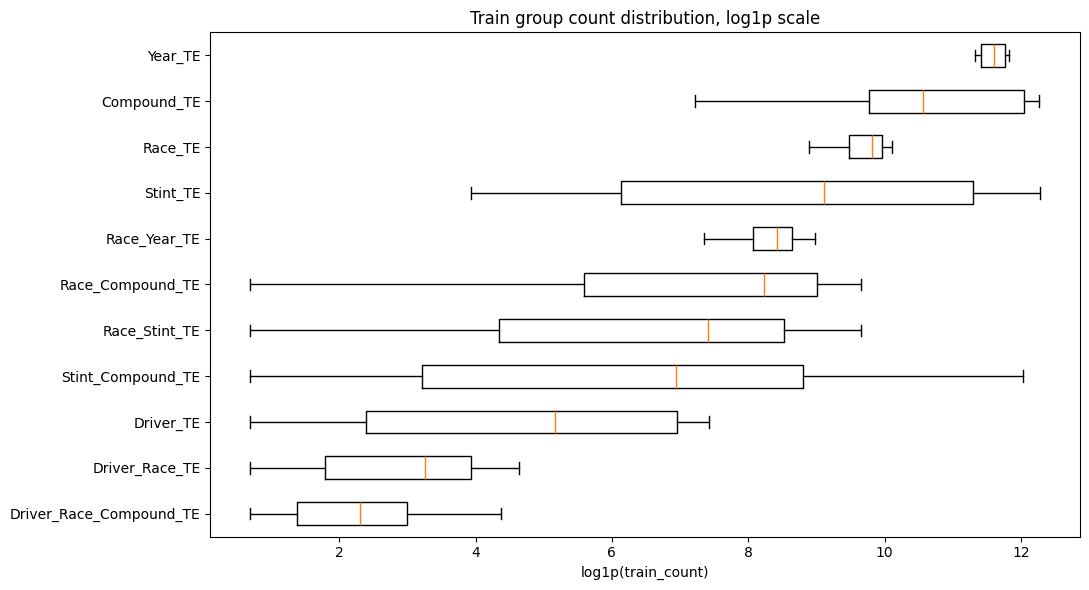

In [6]:
selected_for_distribution = [
    'Compound_TE', 'Race_TE', 'Year_TE', 'Driver_TE', 'Stint_TE',
    'Stint_Compound_TE', 'Race_Stint_TE', 'Race_Compound_TE', 'Race_Year_TE',
    'Driver_Race_TE', 'Driver_Race_Compound_TE',
]
selected_for_distribution = [x for x in selected_for_distribution if x in GROUP_SPECS]

rows = []
for name in selected_for_distribution:
    tbl = group_table(train, test, GROUP_SPECS[name])
    tmp = tbl[tbl['train_count'] > 0][['train_count']].copy()
    tmp['te_name'] = name
    tmp['type'] = GROUP_TYPE[name]
    rows.append(tmp)

dist_df = pd.concat(rows, ignore_index=True)

def boxplot_by_te(dist_df):
    order = dist_df.groupby('te_name')['train_count'].median().sort_values().index.tolist()
    data = [np.log1p(dist_df.loc[dist_df['te_name'] == name, 'train_count']) for name in order]
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.boxplot(data, labels=order, vert=False, showfliers=False)
    ax.set_title('Train group count distribution, log1p scale')
    ax.set_xlabel('log1p(train_count)')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

boxplot_by_te(dist_df)

## 6. Target Rate vs Group Size

这张图看的是：target rate 的变化是否主要来自小样本 group。

如果很多极端 target rate 都在左侧小样本区域，那么这个 TE 风险高，建模时必须强 smoothing，甚至应该放弃。

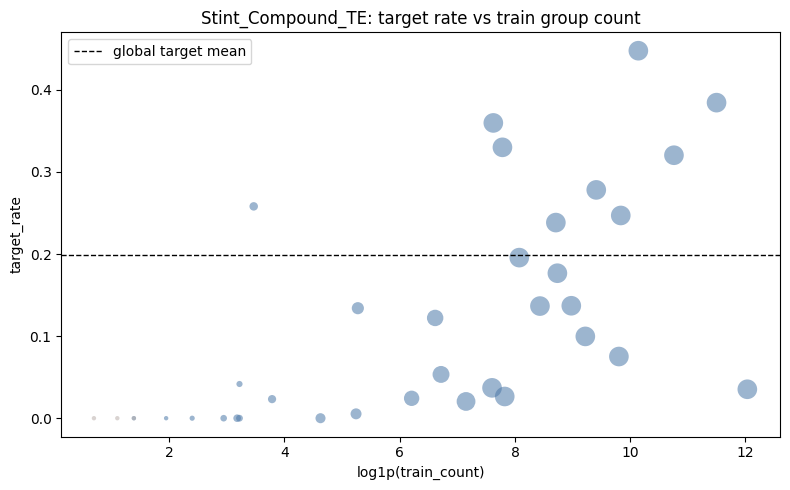

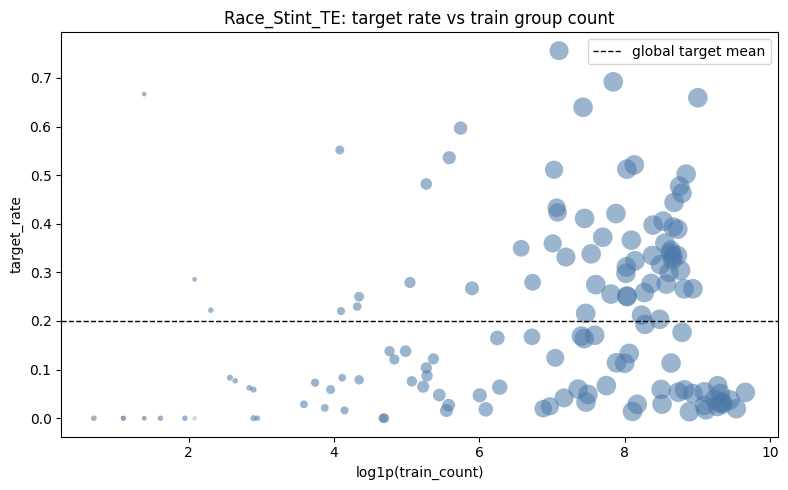

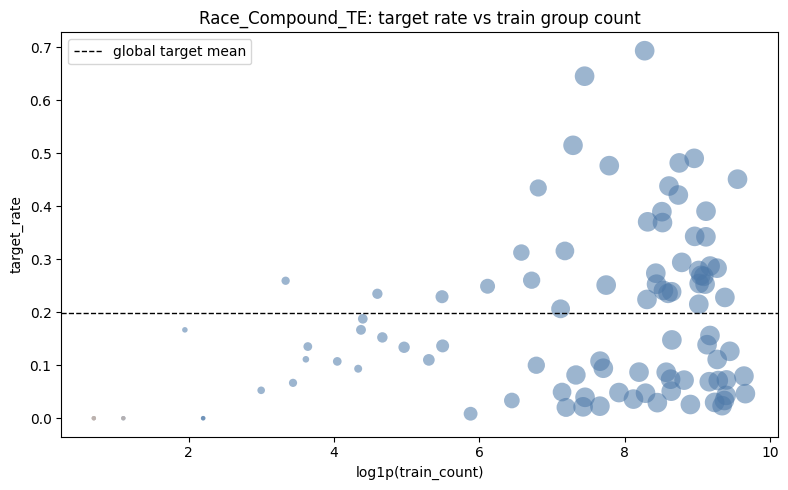

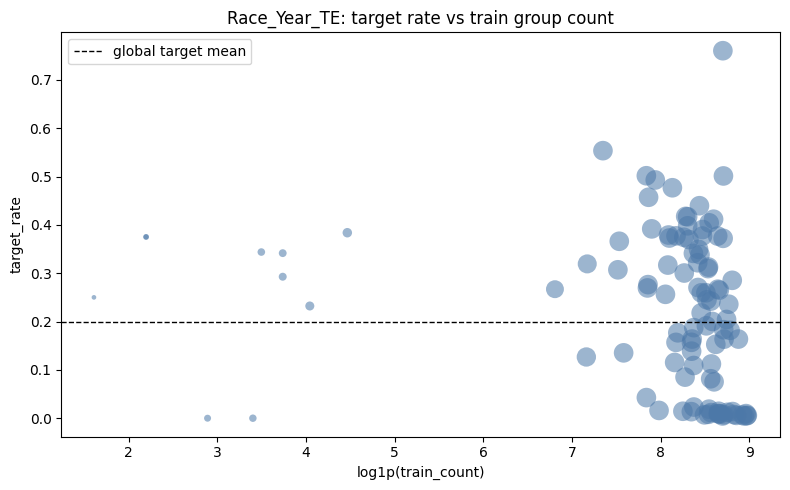

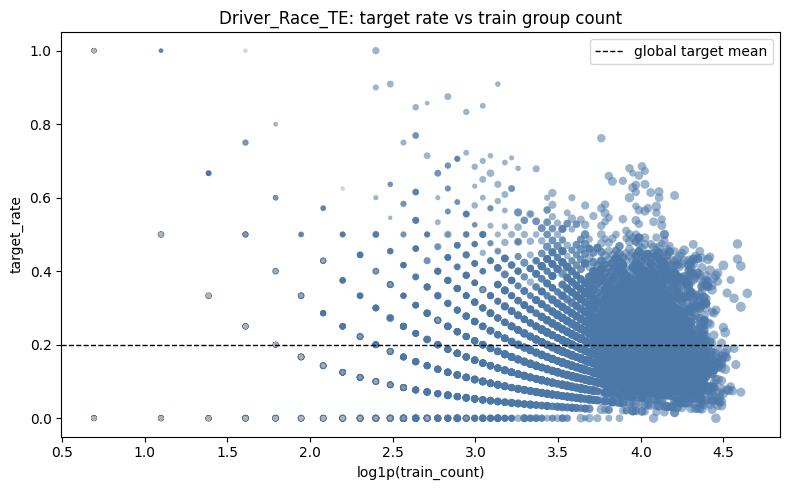

In [7]:
def plot_target_rate_vs_count(te_name):
    cols = GROUP_SPECS[te_name]
    tbl = group_table(train, test, cols)
    tbl = tbl[tbl['train_count'] > 0].copy()
    tbl['log_train_count'] = np.log1p(tbl['train_count'])
    tbl['has_test'] = tbl['test_count'] > 0

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = np.where(tbl['has_test'], '#4c78a8', '#bab0ac')
    sizes = np.clip(np.sqrt(tbl['test_count'].clip(lower=1)) * 8, 10, 200)
    ax.scatter(tbl['log_train_count'], tbl['target_rate'], s=sizes, c=colors, alpha=0.55, edgecolor='none')
    ax.axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1, label='global target mean')
    ax.set_title(f'{te_name}: target rate vs train group count')
    ax.set_xlabel('log1p(train_count)')
    ax.set_ylabel('target_rate')
    ax.legend()
    plt.tight_layout()
    plt.show()

for name in ['Stint_Compound_TE', 'Race_Stint_TE', 'Race_Compound_TE', 'Race_Year_TE', 'Driver_Race_TE']:
    if name in GROUP_SPECS:
        plot_target_rate_vs_count(name)

## 7. Train/Test Top Group Share

这部分看 train/test 的主要 group 分布是否一致。

如果某个 group 在 train 很常见但 test 很少，或者反过来，这个 TE 的线上收益会不稳定。

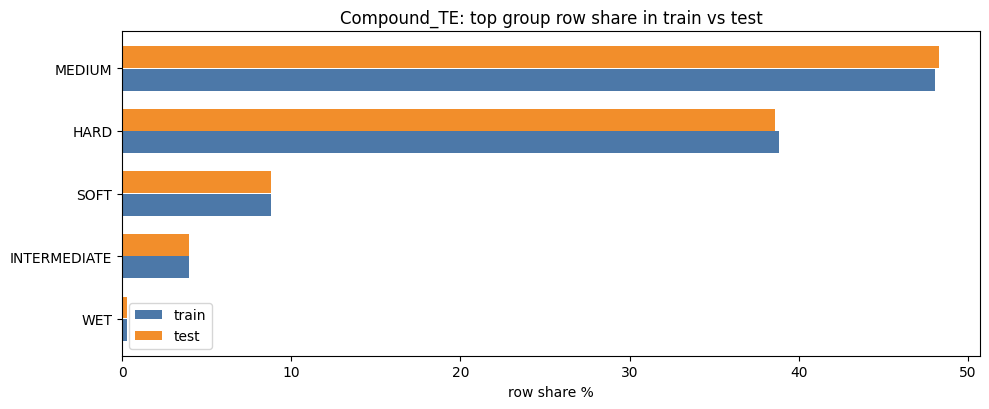

,__key,train_count,test_count,train_share,test_share
2,MEDIUM,211141,90897,0.480806,0.483071
0,HARD,170518,72677,0.388300,0.386241
3,SOFT,38744,16615,0.088227,0.088300
1,INTERMEDIATE,17382,7408,0.039582,0.039370
4,WET,1355,568,0.003086,0.003019


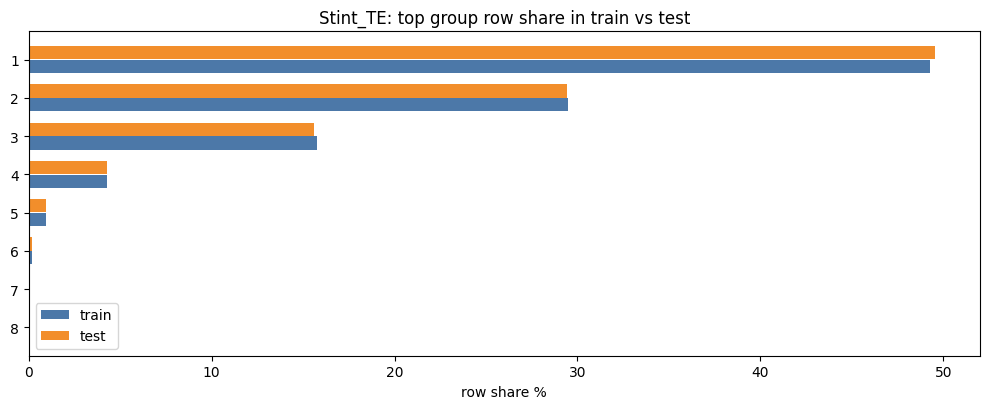

,__key,train_count,test_count,train_share,test_share
0,1,216288,93188,0.492526,0.495246
1,2,129536,55330,0.294977,0.294050
2,3,69238,29381,0.157667,0.156145
3,4,18903,8052,0.043045,0.042792
4,5,4281,1838,0.009749,0.009768
5,6,728,310,0.001658,0.001647
6,7,116,46,0.000264,0.000244
7,8,50,20,0.000114,0.000106


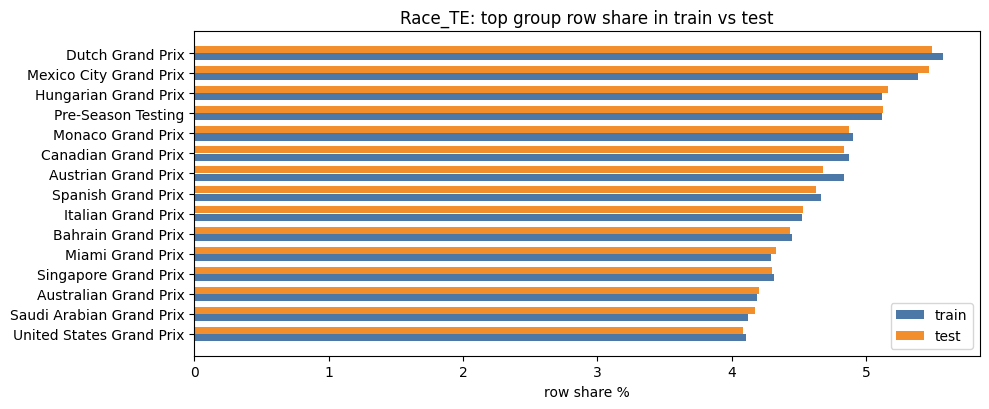

,__key,train_count,test_count,train_share,test_share
9,Dutch Grand Prix,24462,10340,0.055704,0.054952
16,Mexico City Grand Prix,23672,10296,0.053905,0.054718
12,Hungarian Grand Prix,22481,9721,0.051193,0.051662
19,Pre-Season Testing,22492,9647,0.051218,0.051269
18,Monaco Grand Prix,21539,9173,0.049048,0.048750
7,Canadian Grand Prix,21416,9095,0.048768,0.048335
2,Austrian Grand Prix,21223,8806,0.048329,0.046799
23,Spanish Grand Prix,20483,8714,0.046643,0.046310
13,Italian Grand Prix,19854,8531,0.045211,0.045338
4,Bahrain Grand Prix,19535,8347,0.044485,0.044360


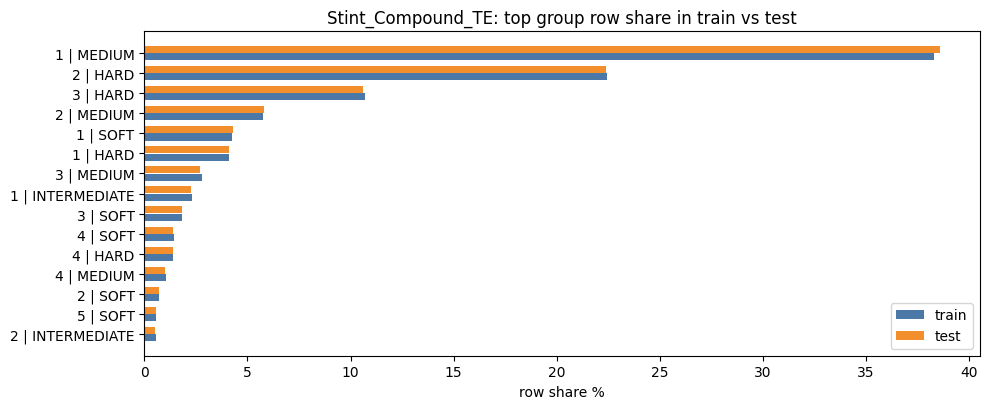

,__key,train_count,test_count,train_share,test_share
2,1 | MEDIUM,168117,72625.0,0.382832,0.385964
5,2 | HARD,98535,42086.0,0.224382,0.223665
10,3 | HARD,47055,19971.0,0.107153,0.106136
7,2 | MEDIUM,25363,10948.0,0.057756,0.058183
3,1 | SOFT,18694,8053.0,0.042570,0.042798
0,1 | HARD,18098,7731.0,0.041212,0.041086
12,3 | MEDIUM,12217,5046.0,0.027820,0.026817
1,1 | INTERMEDIATE,10105,4257.0,0.023011,0.022624
13,3 | SOFT,7920,3438.0,0.018035,0.018271
17,4 | SOFT,6222,2657.0,0.014169,0.014121


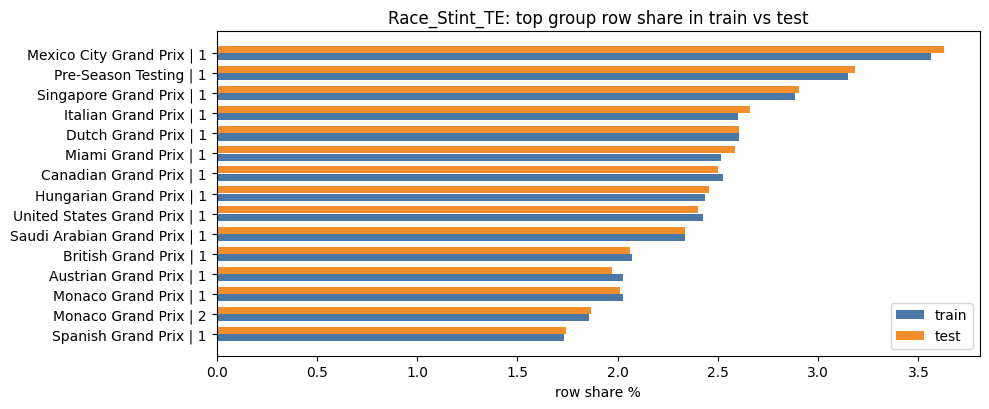

,__key,train_count,test_count,train_share,test_share
92,Mexico City Grand Prix | 1,15655.0,6823.0,0.035649,0.036261
112,Pre-Season Testing | 1,13832.0,5995.0,0.031498,0.031860
129,Singapore Grand Prix | 1,12675.0,5463.0,0.028863,0.029033
76,Italian Grand Prix | 1,11425.0,5002.0,0.026017,0.026583
53,Dutch Grand Prix | 1,11433.0,4898.0,0.026035,0.026030
98,Miami Grand Prix | 1,11048.0,4864.0,0.025158,0.025850
42,Canadian Grand Prix | 1,11096.0,4709.0,0.025268,0.025026
70,Hungarian Grand Prix | 1,10703.0,4616.0,0.024373,0.024532
148,United States Grand Prix | 1,10651.0,4516.0,0.024254,0.024000
125,Saudi Arabian Grand Prix | 1,10266.0,4394.0,0.023378,0.023352


In [8]:
def top_group_share(te_name, top_n=20):
    cols = GROUP_SPECS[te_name]
    tr = (
        train.groupby(cols, dropna=False)
        .size()
        .rename('train_count')
        .reset_index()
    )
    te = (
        test.groupby(cols, dropna=False)
        .size()
        .rename('test_count')
        .reset_index()
    )
    merged = tr.merge(te, on=cols, how='outer').fillna(0)
    merged['train_share'] = merged['train_count'] / len(train)
    merged['test_share'] = merged['test_count'] / len(test)
    merged['__key'] = make_display_key(merged, cols)
    merged['max_share'] = merged[['train_share', 'test_share']].max(axis=1)
    merged = merged.sort_values('max_share', ascending=False).head(top_n).sort_values('max_share')

    fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.28)))
    y = np.arange(len(merged))
    ax.barh(y - 0.18, merged['train_share'] * 100, height=0.35, label='train', color='#4c78a8')
    ax.barh(y + 0.18, merged['test_share'] * 100, height=0.35, label='test', color='#f28e2b')
    ax.set_yticks(y)
    ax.set_yticklabels(merged['__key'])
    ax.set_xlabel('row share %')
    ax.set_title(f'{te_name}: top group row share in train vs test')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return merged.sort_values('max_share', ascending=False)[['__key', 'train_count', 'test_count', 'train_share', 'test_share']]

for name in ['Compound_TE', 'Stint_TE', 'Race_TE', 'Stint_Compound_TE', 'Race_Stint_TE']:
    if name in GROUP_SPECS:
        display(top_group_share(name, top_n=15))

## 8. Smoothed TE Value Inspection

真正训练模型时不应该直接用 full train mean，需要做 OOF TE。这里仅用于分析每个 group 的 smoothed target rate 是否稳定。

公式：

```text
smoothed_te = (group_sum + prior * smoothing) / (group_count + smoothing)
```

`smoothing` 越大，小样本 group 越接近全局均值。

In [9]:
def smoothed_group_values(te_name, smoothing=50, top_n=30):
    cols = GROUP_SPECS[te_name]
    tbl = group_table(train, test, cols)
    prior = train[TARGET].mean()
    tbl['smoothed_te'] = (tbl['target_rate'] * tbl['train_count'] + prior * smoothing) / (tbl['train_count'] + smoothing)
    tbl['abs_from_prior'] = (tbl['smoothed_te'] - prior).abs()
    out = tbl[tbl['train_count'] > 0].sort_values('abs_from_prior', ascending=False).head(top_n)
    return out[['__key', 'train_count', 'test_count', 'target_rate', 'smoothed_te', 'abs_from_prior']]

for name in ['Stint_Compound_TE', 'Race_Stint_TE', 'Race_Compound_TE', 'Race_Year_TE']:
    if name in GROUP_SPECS:
        print('\n', '=' * 80)
        print(name)
        display(smoothed_group_values(name, smoothing=50, top_n=20))


Stint_Compound_TE


,__key,train_count,test_count,target_rate,smoothed_te,abs_from_prior
7,2 | MEDIUM,25363,10948,0.447699,0.447210,0.248228
5,2 | HARD,98535,42086,0.384432,0.384338,0.185356
4,1 | WET,1274,522,0.020408,0.027152,0.171830
22,5 | SOFT,2494,1080,0.026464,0.029854,0.169128
2,1 | MEDIUM,168117,72625,0.035261,0.035310,0.163672
25,6 | INTERMEDIATE,495,234,0.024242,0.040274,0.158709
15,4 | INTERMEDIATE,2001,885,0.036982,0.040931,0.158051
11,3 | INTERMEDIATE,2046,926,0.359726,0.355892,0.156910
27,6 | SOFT,188,61,0.005319,0.046005,0.152977
21,5 | MEDIUM,825,345,0.053333,0.061656,0.137326



Race_Stint_TE


,__key,train_count,test_count,target_rate,smoothed_te,abs_from_prior
50,Chinese Grand Prix | 3,1205,553,0.756017,0.733824,0.534842
49,Chinese Grand Prix | 2,2542,1079,0.691975,0.682465,0.483483
105,Monaco Grand Prix | 2,8151,3510,0.659306,0.656499,0.457517
63,Emilia Romagna Grand Prix | 3,1676,744,0.639618,0.626853,0.427871
68,French Grand Prix | 3,310,138,0.596774,0.541525,0.342543
31,Belgian Grand Prix | 2,3395,1426,0.521060,0.516386,0.317404
106,Monaco Grand Prix | 3,3066,1287,0.512394,0.507365,0.308383
126,Saudi Arabian Grand Prix | 2,6932,3087,0.502164,0.499993,0.301011
67,French Grand Prix | 2,1125,468,0.511111,0.497829,0.298847
64,Emilia Romagna Grand Prix | 4,265,131,0.535849,0.482378,0.283396



Race_Compound_TE


,__key,train_count,test_count,target_rate,smoothed_te,abs_from_prior
31,Chinese Grand Prix | HARD,3917,1701,0.693132,0.686904,0.487922
19,Belgian Grand Prix | HARD,1713,651,0.645067,0.632416,0.433434
42,French Grand Prix | HARD,1461,614,0.514716,0.504268,0.305286
79,Saudi Arabian Grand Prix | HARD,7747,3412,0.490125,0.488258,0.289276
34,Dutch Grand Prix | HARD,6305,2561,0.481523,0.479300,0.280318
17,Bahrain Grand Prix | MEDIUM,2406,1006,0.476309,0.470663,0.271681
66,Monaco Grand Prix | HARD,14060,6004,0.450853,0.449961,0.250979
38,Emilia Romagna Grand Prix | HARD,5474,2437,0.437888,0.435726,0.236744
99,United States Grand Prix | SOFT,905,365,0.434254,0.421936,0.222954
89,Spanish Grand Prix | MEDIUM,6226,2696,0.420977,0.419208,0.220226



Race_Year_TE


,__key,train_count,test_count,target_rate,smoothed_te,abs_from_prior
74,Monaco Grand Prix | 2024,6002,2652,0.760247,0.755610,0.556627
23,Belgian Grand Prix | 2025,1552,664,0.553479,0.542415,0.343433
94,Spanish Grand Prix | 2024,6040,2489,0.501159,0.498678,0.299696
24,British Grand Prix | 2022,2532,1124,0.501580,0.495720,0.296738
58,Japanese Grand Prix | 2024,2800,1200,0.492857,0.487701,0.288719
19,Bahrain Grand Prix | 2025,3396,1515,0.476737,0.472707,0.273725
14,Azerbaijan Grand Prix | 2024,2597,1165,0.457066,0.452191,0.253209
62,Las Vegas Grand Prix | 2024,4609,1938,0.439575,0.436993,0.238011
95,Spanish Grand Prix | 2025,3947,1751,0.417532,0.414798,0.215816
16,Bahrain Grand Prix | 2022,4034,1626,0.416708,0.414042,0.215060


## 9. Candidate Decision Table

这个表给每个 TE 分组一个粗略风险标签，方便决定下一步是否值得做成 ver13 / ver14。

默认规则比较保守：

- `good_candidate`：test unseen 很低，且 test 大部分行能被 train 中 count >= 50 的 group 覆盖
- `ok_but_needs_ablation`：覆盖还可以，但需要单独 ablation
- `risky_sparse_or_unseen`：稀疏或 unseen 风险较高
- `driver_high_risk`：Driver 组合，默认高风险

In [10]:
def risk_label(row):
    if row['type'] == 'high_risk_driver_combo':
        return 'driver_high_risk'
    if row['test_unseen_row_pct'] <= 0.001 and row['test_covered_count_ge_50_row_pct'] >= 0.98:
        return 'good_candidate'
    if row['test_unseen_row_pct'] <= 0.01 and row['test_covered_count_ge_20_row_pct'] >= 0.95:
        return 'ok_but_needs_ablation'
    return 'risky_sparse_or_unseen'

candidate = summary.copy()
candidate['risk_label'] = candidate.apply(risk_label, axis=1)
show_cols = [
    'te_name', 'type', 'columns', 'risk_label',
    'train_groups', 'test_groups', 'test_unseen_row_pct',
    'train_count_p10', 'train_count_median',
    'test_covered_count_ge_20_row_pct', 'test_covered_count_ge_50_row_pct',
    'test_low_count_lt_20_row_pct',
]

candidate_show = candidate[show_cols].copy()
for c in ['test_unseen_row_pct', 'test_covered_count_ge_20_row_pct', 'test_covered_count_ge_50_row_pct', 'test_low_count_lt_20_row_pct']:
    candidate_show[c] = (candidate_show[c] * 100).round(3)
candidate_show[['train_count_p10', 'train_count_median']] = candidate_show[['train_count_p10', 'train_count_median']].round(2)
candidate_show.sort_values(['risk_label', 'type', 'test_unseen_row_pct', 'train_count_median'], ascending=[True, True, True, False])

,te_name,type,columns,risk_label,train_groups,test_groups,test_unseen_row_pct,train_count_p10,train_count_median,test_covered_count_ge_20_row_pct,test_covered_count_ge_50_row_pct,test_low_count_lt_20_row_pct
7,Driver_Compound_TE,high_risk_driver_combo,Driver x Compound,driver_high_risk,2947,2647,0.047,1.0,46.0,98.501,96.195,1.452
8,Driver_Stint_TE,high_risk_driver_combo,Driver x Stint,driver_high_risk,3859,3386,0.116,1.0,19.0,97.472,94.309,2.411
9,Driver_Race_TE,high_risk_driver_combo,Driver x Race,driver_high_risk,14942,13651,0.318,2.0,25.0,89.220,52.594,10.462
10,Driver_Race_Compound_TE,high_risk_driver_combo,Driver x Race x Compound,driver_high_risk,34027,29686,1.120,1.0,9.0,55.579,3.769,43.301
6,PitStop_TE,coarse_single_field,PitStop,good_candidate,2,2,0.000,91734.0,219570.0,100.000,100.000,0.000
5,Year_TE,coarse_single_field,Year,good_candidate,4,4,0.000,85960.5,110002.0,100.000,100.000,0.000
4,Compound_TE,coarse_single_field,Compound,good_candidate,5,5,0.000,7765.8,38744.0,100.000,100.000,0.000
3,Position_TE,coarse_single_field,Position,good_candidate,20,20,0.000,15343.6,24341.5,100.000,100.000,0.000
2,Race_TE,coarse_single_field,Race,good_candidate,26,26,0.000,10249.5,18258.5,100.000,100.000,0.000
1,Stint_TE,coarse_single_field,Stint,good_candidate,8,8,0.000,96.2,11592.0,100.000,100.000,0.000


## 10. What To Test Next

建议根据上面的 summary 和图来决定：

1. 如果 `Stint_Compound_TE` 是 `good_candidate` 或 `ok_but_needs_ablation`，可以作为 `ver13` 单独测试。
2. 如果 `Race_Stint_TE` 覆盖率足够，作为 `ver14` 单独测试。
3. 如果两者 OOF 和 Public 都不超过 baseline，就停止 TE 主线，转向 seed ensemble / prediction blending。
4. Driver 相关组合即使图上 target rate 看起来差异大，也要优先怀疑稀疏噪声。

保留标准：

```text
OOF > 0.95368 且 Public > 0.95355：保留
OOF 低于 baseline 且 Public 低于 baseline：放弃
OOF 高但 Public 低：谨慎，可能 CV 不稳定
Public 高但 OOF 低：可能 LB lucky，不轻易作为主线
```